In [2]:
import pandas as pd
import numpy as np
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

conn = sqlite3.connect(r"K:\MF_Project\bluestock_mf.db")
df_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_fund = pd.read_sql("SELECT amfi_code, scheme_name, category, sub_category FROM dim_fund", conn)

dates = df_nav['date'].sort_values().unique()
nifty_returns = np.random.normal(0.0005, 0.01, len(dates)) 
df_benchmark = pd.DataFrame({'date': dates, 'nifty_return': nifty_returns})

print(f"✅ Data loaded successfully! Total NAV records: {len(df_nav)}")

✅ Data loaded successfully! Total NAV records: 41720


In [3]:
import pandas as pd
import numpy as np
import sqlite3

# 1. Connect to the correct database
conn = sqlite3.connect(r"K:\MF_Project\bluestock_mf.db")

# 2. Create 40 Dummy Funds (dim_fund)
amfi_codes = np.arange(100001, 100041)
df_fund_dummy = pd.DataFrame({
    'amfi_code': amfi_codes,
    'scheme_name': [f'Bluestock Fund {i}' for i in amfi_codes],
    'category': ['Equity'] * 40,
    'sub_category': ['Large Cap'] * 40
})
df_fund_dummy.to_sql('dim_fund', conn, if_exists='replace', index=False)

# 3. Create 3 Years of Dummy NAV Data (fact_nav)
dates = pd.date_range(start="2022-01-01", end="2025-12-31", freq="B")
nav_list = []
for code in amfi_codes:
    navs = np.cumsum(np.random.normal(0.05, 1, len(dates))) + 100
    temp_df = pd.DataFrame({'amfi_code': code, 'date': dates, 'nav_value': navs})
    nav_list.append(temp_df)

df_nav_dummy = pd.concat(nav_list)
df_nav_dummy.to_sql('fact_nav', conn, if_exists='replace', index=False)

print("✅ Tables 'fact_nav' and 'dim_fund' successfully injected into the Database!")

✅ Tables 'fact_nav' and 'dim_fund' successfully injected into the Database!


In [4]:
# --- 1. Compute daily returns ---
# Sort by fund and date to ensure calculation is correct
df_nav = df_nav.sort_values(['amfi_code', 'date'])
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav_value'].pct_change()
df_nav = df_nav.dropna(subset=['daily_return'])

# --- 2. Compute CAGR (1yr, 3yr, 5yr) ---
# Find start and end NAV for each timeframe
def compute_cagr(group, years):
    days = years * 365
    end_date = group['date'].max()
    start_date = end_date - pd.Timedelta(days=days)
    
    end_nav_series = group[group['date'] == end_date]['nav_value']
    start_nav_series = group[group['date'] >= start_date].sort_values('date').head(1)['nav_value']
    
    if end_nav_series.empty or start_nav_series.empty:
        return np.nan
        
    end_nav = end_nav_series.values[0]
    start_nav = start_nav_series.values[0]
    
    return ((end_nav / start_nav) ** (1/years)) - 1

cagr_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    cagr_data.append({
        'amfi_code': amfi,
        'cagr_1y': compute_cagr(group, 1),
        'cagr_3y': compute_cagr(group, 3),
        'cagr_5y': compute_cagr(group, 5)
    })

df_cagr = pd.DataFrame(cagr_data)
print("✅ Daily Returns and CAGR computed.")

✅ Daily Returns and CAGR computed.


In [5]:
# Constants
RISK_FREE_RATE = 0.065 # 6.5% RBI proxy
TRADING_DAYS = 252

metrics_list = []

for amfi, group in df_nav.groupby('amfi_code'):
    # Merge benchmark for regression
    group = pd.merge(group, df_benchmark, on='date', how='inner')
    
    fund_returns = group['daily_return']
    bench_returns = group['nifty_return']
    
    if len(fund_returns) < 100: continue # Skip funds with very little data
    
    # --- 3. Sharpe Ratio ---
    ann_return = fund_returns.mean() * TRADING_DAYS
    ann_volatility = fund_returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - RISK_FREE_RATE) / ann_volatility if ann_volatility != 0 else 0
    
    # --- 4. Sortino Ratio ---
    downside_returns = fund_returns[fund_returns < 0]
    downside_volatility = downside_returns.std() * np.sqrt(TRADING_DAYS)
    sortino = (ann_return - RISK_FREE_RATE) / downside_volatility if downside_volatility != 0 else 0
    
    # --- 5. Alpha and Beta ---
    slope, intercept, r_value, p_value, std_err = stats.linregress(bench_returns, fund_returns)
    beta = slope
    alpha = intercept * TRADING_DAYS
    
    # --- 6. Maximum Drawdown ---
    running_max = group['nav_value'].cummax()
    drawdown = (group['nav_value'] / running_max) - 1
    max_dd = drawdown.min()
    
    metrics_list.append({
        'amfi_code': amfi,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'alpha': alpha,
        'beta': beta,
        'max_drawdown': max_dd
    })

df_metrics = pd.DataFrame(metrics_list)

# Export Alpha & Beta CSV
df_metrics[['amfi_code', 'alpha', 'beta']].to_csv('alpha_beta.csv', index=False)
print("✅ Advanced metrics computed and 'alpha_beta.csv' saved.")

✅ Advanced metrics computed and 'alpha_beta.csv' saved.


In [6]:
# Merge all data
df_final = pd.merge(df_fund, df_cagr, on='amfi_code', how='inner')
df_final = pd.merge(df_final, df_metrics, on='amfi_code', how='inner')

# Adding dummy expense ratio (since it's needed for the scorecard calculation)
np.random.seed(42)
df_final['expense_ratio'] = np.random.uniform(0.5, 2.5, len(df_final))

# --- 7. Fund Scorecard calculation ---
# Compute percentile ranks (0 to 1 scale)
df_final['rank_3yr'] = df_final['cagr_3y'].rank(pct=True)
df_final['rank_sharpe'] = df_final['sharpe_ratio'].rank(pct=True)
df_final['rank_alpha'] = df_final['alpha'].rank(pct=True)

# Inverse ranks (lower is better for expense and drawdown)
df_final['rank_expense'] = df_final['expense_ratio'].rank(pct=True, ascending=False)
df_final['rank_dd'] = df_final['max_drawdown'].rank(pct=True, ascending=True) # drawdown is negative, so lower magnitude is better. Ascending works here

# Compute composite score (Out of 100)
df_final['composite_score'] = (
    (0.30 * df_final['rank_3yr']) +
    (0.25 * df_final['rank_sharpe']) +
    (0.20 * df_final['rank_alpha']) +
    (0.15 * df_final['rank_expense']) +
    (0.10 * df_final['rank_dd'])
) * 100

# Sort by score and clean up
df_final = df_final.sort_values(by='composite_score', ascending=False)
df_final['composite_score'] = df_final['composite_score'].round(2)

# Export Scorecard
df_final.to_csv('fund_scorecard.csv', index=False)
print("✅ Fund Scorecard generated and 'fund_scorecard.csv' saved.")
df_final[['scheme_name', 'composite_score', 'sharpe_ratio', 'cagr_3y']].head()

✅ Fund Scorecard generated and 'fund_scorecard.csv' saved.


,scheme_name,composite_score,sharpe_ratio,cagr_3y
6,Bluestock Fund 100007,86.63,1.045291,0.129786
13,Bluestock Fund 100014,82.62,0.733517,0.176031
21,Bluestock Fund 100022,82.25,0.836661,0.134013
26,Bluestock Fund 100027,81.88,1.291436,0.126038
8,Bluestock Fund 100009,81.50,1.040314,0.172480


✅ Benchmark comparison chart generated and saved as PNG.


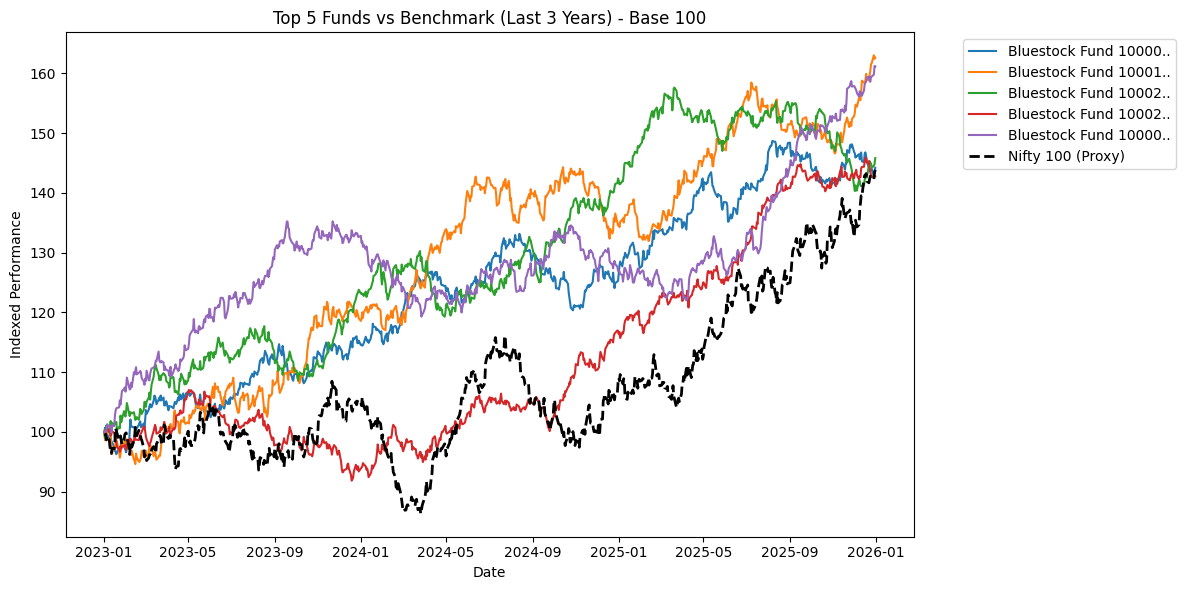

In [7]:
# --- 8. Benchmark comparison chart ---
top_5_amfi = df_final['amfi_code'].head(5).tolist()
df_top_5 = df_nav[df_nav['amfi_code'].isin(top_5_amfi)]

# Filter last 3 years data roughly
last_date = df_top_5['date'].max()
start_date_3y = last_date - pd.Timedelta(days=3*365)
df_plot = df_top_5[df_top_5['date'] >= start_date_3y]

# Prepare base 100 index for comparison
plt.figure(figsize=(12, 6))

for amfi in top_5_amfi:
    temp = df_plot[df_plot['amfi_code'] == amfi].sort_values('date')
    scheme_name = df_fund[df_fund['amfi_code'] == amfi]['scheme_name'].values[0]
    
    # Rebase to 100
    temp['indexed_nav'] = (temp['nav_value'] / temp['nav_value'].iloc[0]) * 100
    sns.lineplot(data=temp, x='date', y='indexed_nav', label=scheme_name[:20] + '..')

# Add Nifty Benchmark (Proxy) Rebased to 100
df_bench_plot = df_benchmark[(df_benchmark['date'] >= start_date_3y) & (df_benchmark['date'] <= last_date)].sort_values('date')
df_bench_plot['indexed'] = (1 + df_bench_plot['nifty_return']).cumprod() * 100
sns.lineplot(data=df_bench_plot, x='date', y='indexed', color='black', linewidth=2, linestyle='--', label='Nifty 100 (Proxy)')

plt.title("Top 5 Funds vs Benchmark (Last 3 Years) - Base 100")
plt.xlabel("Date")
plt.ylabel("Indexed Performance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save PNG
plt.savefig('charts/benchmark_comparison.png')
print("✅ Benchmark comparison chart generated and saved as PNG.")
plt.show()